[*********************100%***********************]  1 of 1 completed


Price        Close    High     Low    Open Volume
Ticker       TRY=X   TRY=X   TRY=X   TRY=X  TRY=X
Date                                             
2010-01-01  1.4955  1.5024  1.4425  1.4959      0
2010-02-01  1.5489  1.5627  1.4777  1.4954      0
2010-03-01  1.5156  1.5529  1.5103  1.5487      0
2010-04-01  1.4880  1.5200  1.4690  1.5155      0
2010-05-01  1.5718  1.6204  1.4823  1.4823      0


C:\Users\necla\AppData\Local\Temp\ipykernel_15824\2851366800.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'Close': 'USDTRY'}, inplace=True)


Price   Ticker
USDTRY  TRY=X     0
dtype: int64


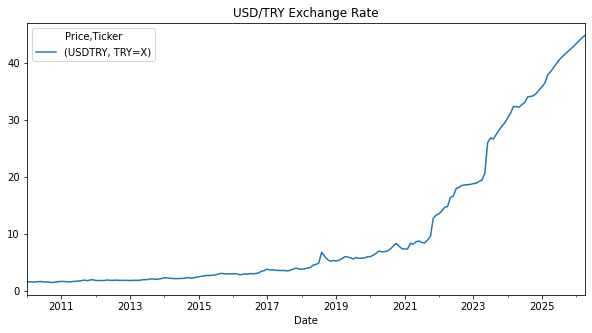

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Fetch monthly USD/TRY data
data_monthly = yf.download("TRY=X", start="2010-01-01", interval="1mo")

# First few rows
print(data_monthly.head())

# Select only the Close price
df = data_monthly[['Close']]

# Rename the column
df.rename(columns={'Close': 'USDTRY'}, inplace=True)

# Check for missing data
print(df.isnull().sum())

# Visualize the data
df.plot(figsize=(10,5), title="USD/TRY Exchange Rate")
plt.show()

In [2]:
df_m = data_monthly[['Close']].copy()
df_m.columns = ['USDTRY'] 
df_m.dropna(inplace=True)

In [3]:
from statsmodels.tsa.stattools import adfuller

# Stationarity test (ADF)
result = adfuller(df['USDTRY'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: 4.235682253918813
p-value: 1.0
Critical Values:
1%: -3.4645146202692527
5%: -2.8765564361715534
10%: -2.5747745328940375


In [4]:
print(df.head()) 

result = adfuller(df['USDTRY'].dropna())

Price       USDTRY
Ticker       TRY=X
Date              
2010-01-01  1.4955
2010-02-01  1.5489
2010-03-01  1.5156
2010-04-01  1.4880
2010-05-01  1.5718


--- Logaritmik Fark ADF Sonuçları ---
ADF İstatistiği: -12.501055180612912
p-value: 2.805994073156874e-23


C:\Users\necla\AppData\Local\Temp\ipykernel_15824\860588249.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Log_Return'] = np.log(df['USDTRY'] / df['USDTRY'].shift(1))


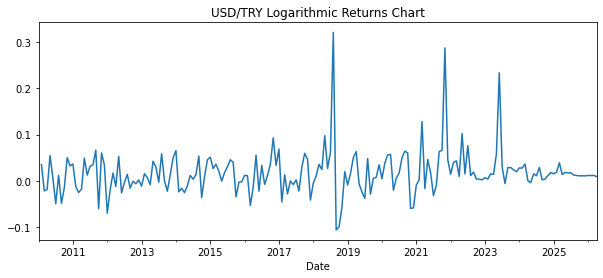

In [5]:
import numpy as np

# 1. Calculate Logarithmic Returns (First Difference)
# We use log returns to achieve stationarity in the time series.
df['Log_Return'] = np.log(df['USDTRY'] / df['USDTRY'].shift(1))

# 2. Remove the first row as it contains a NaN value due to differencing
df_log = df['Log_Return'].dropna()

# Perform ADF Test on the transformed series to verify stationarity
result_diff = adfuller(df_log)

print("--- Logaritmik Fark ADF Sonuçları ---")
print(f"ADF İstatistiği: {result_diff[0]}")
print(f"p-value: {result_diff[1]}")

# 4. Visualization of the Stationary Series
df['Log_Return'].plot(figsize=(10,4), title="USD/TRY Logarithmic Returns Chart")
plt.show()

C:\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


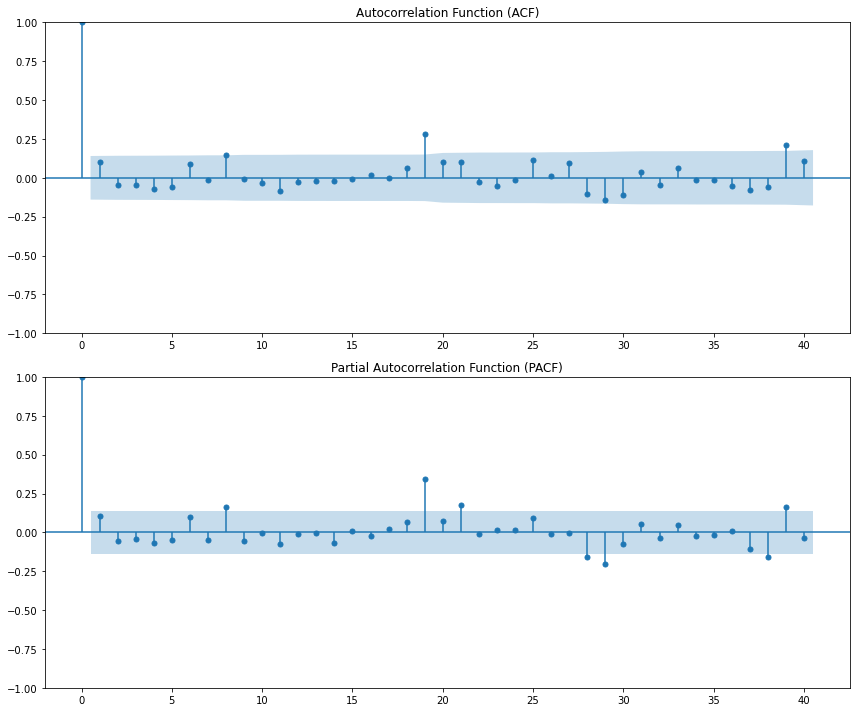

In [6]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Forecasting with the best model
# Set figure dimensions
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

#ACF Plot (Used to determine the MA - q parameter)
plot_acf(df_log, lags=40, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# PACF Plot (Used to determine the AR - p parameter)
plot_pacf(df_log, lags=40, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [7]:
# Model 1
model1 = ARIMA(df_log, order=(1, 0, 1)).fit()

# Model 2
model2 = ARIMA(df_log, order=(2, 0, 2)).fit()

print(f"Model 1 AIC: {model1.aic}")
print(f"Model 2 AIC: {model2.aic}")

C:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\lib\site-packages

Model 1 AIC: -628.093705061297
Model 2 AIC: -626.2229615328254


C:\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [8]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(p, d, q) -> p=1, d=0, q=1
model = ARIMA(df_log, order=(1, 0, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                  195
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 318.047
Date:                Tue, 21 Apr 2026   AIC                           -628.094
Time:                        11:49:21   BIC                           -615.002
Sample:                    02-01-2010   HQIC                          -622.793
                         - 04-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0174      0.005      3.406      0.001       0.007       0.027
ar.L1         -0.1918      0.506     -0.379      0.704      -1.183       0.799
ma.L1          0.3011      0.498      0.605      0.5

C:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


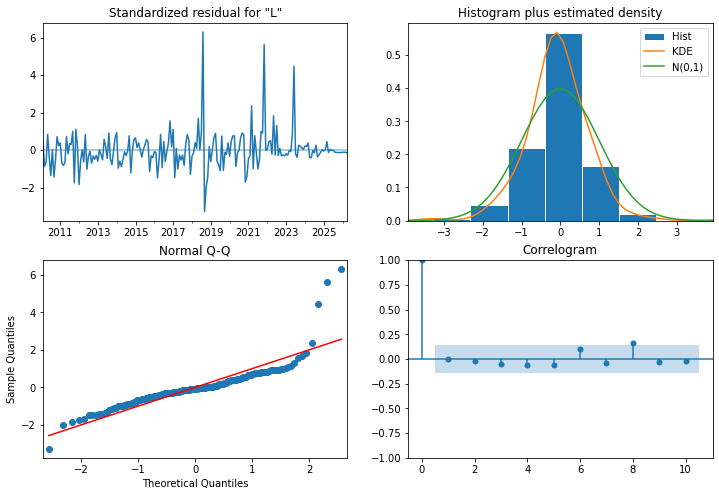

In [9]:
# --- RESIDUAL DIAGNOSTICS ---

# Visualizing model residuals (errors)
# This step is crucial to check if the residuals behave like white noise.
model_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

In [10]:
 # --- FINAL FORECASTING ---

# 1. Forecasting with our best fit: ARIMA(1,0,1)
forecast_steps = 3
final_forecast_obj = model1.get_forecast(steps=forecast_steps)
final_forecast_df = final_forecast_obj.summary_frame()

# 2. Reverting Log-Returns back to Actual Prices
# Since the model was built on first-differences (log-returns), 
# we need to transform the results back to the original price scale.
last_price = df_m['USDTRY'].iloc[-1]
final_prices = []
cumulative_log_val = 0

for log_val in final_forecast_df['mean']:
    cumulative_log_val += log_val
    # Calculation Formula: Future Price = Last Actual Price * e^(Cumulative Log Return)
    p_val = last_price * np.exp(cumulative_log_val)
    final_prices.append(p_val)

# 3. Generating Future Dates (Next 3 Months)
forecast_dates = pd.date_range(start=df_m.index[-1], periods=forecast_steps + 1, freq='MS')[1:]
final_prediction_table = pd.DataFrame({'Forecast USD/TRY': final_prices}, index=forecast_dates)

print("--- 3-MONTH USD/TRY EXCHANGE RATE FORECAST ---")
print(final_prediction_table)

--- 3-MONTH USD/TRY EXCHANGE RATE FORECAST ---
            Forecast USD/TRY
2026-05-01         45.650288
2026-06-01         46.460302
2026-07-01         47.276707


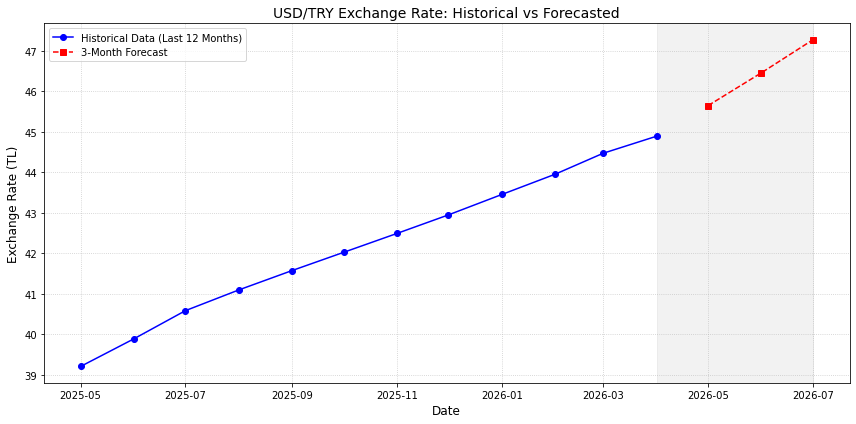

In [12]:
# --- VISUALIZING THE FINAL FORECAST ---

import matplotlib.pyplot as plt

# 1. Select the last 12 months of actual data for better visualization
actual_data_tail = df_m['USDTRY'].tail(12)

# 2. Plotting
plt.figure(figsize=(12, 6))

# Plot actual historical data
plt.plot(actual_data_tail.index, actual_data_tail.values, 
         label='Historical Data (Last 12 Months)', color='blue', marker='o')

# Plot forecasted data
plt.plot(final_prediction_table.index, final_prediction_table['Forecast USD/TRY'], 
         label='3-Month Forecast', color='red', linestyle='--', marker='s')

# 3. Chart Details
plt.title('USD/TRY Exchange Rate: Historical vs Forecasted', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Exchange Rate (TL)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Highlight the forecast area
plt.axvspan(actual_data_tail.index[-1], final_prediction_table.index[-1], 
            color='gray', alpha=0.1)

plt.tight_layout()
plt.show()